In [1]:
import numpy as np
from bhjet import RadiationZone
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
erg2eV = 6.242e+11 #1erg in eV
c = 3e10 # cm/s

make a new RadiationZone object, all these parameters are optional and will otherwise have default values

In [3]:
rad = RadiationZone(
    magnetic_field=1, # G
    radius=1e17, # cm
    height=1e15, # cm, irrelevant when geometry=sphere
    geometry="sphere",
    bulk_momentum=1, # beta*Gamma
    theta_obs=20, # degree
    distance=1e4, # kpc
    redshift=0.001, 
    electron_number_density=1e3, # 1/cm³
    proton_number_density=1, # 1/cm³
    electron_temperature=1e3, # keV
    proton_temperature=1e3, # keV
    fraction_nonthermal_electrons=0.1, 
    fraction_nonthermal_protons=0.1, 
    factor_break_electrons=1, 
    factor_break_protons=1, 
    factor_max_energy_electrons=1, 
    factor_max_energy_protons=1, 
    index_injected_electrons=2, 
    index_injected_protons=2, 
    include_counterjet=True, 
    force_compton_calculation=True, 
    compton_switch=True, # only used when force_compton_calculation=True
    compton_threshold=1e-2, # only used when force_compton_calculation=False
    profile_time=True,
    verbosity_level=1
)

These parameters can be accessed also as variables

In [4]:
print(rad.bulk_momentum)
rad.bulk_momentum = 9
print(rad.bulk_momentum)

1.0
9.0


It is possible to add add multiple black bodies and index them with a name. The temperature and energy density are treated as in the observers frame, and then boosted to the comoving quantites.
After all additional targets are added, first the particle distributions are calulated and then their emission, which is interpolated to a given grid (or without an argument to a default grid).

In [5]:
# temperature in keV, energy_density in erg/cm³
rad.add_target_black_body(temperature=1e-3, energy_density=1e-2, name="bb1")
rad.add_target_black_body(temperature=1e-6, energy_density=1e-3, name="bb2")
rad.compute_particles()
energy_grid_flux = np.logspace(-6, 16, 300) / erg2eV
rad.compute_radiation(energy_grid_flux)

com min 3.2642e+09Hz, com max 8.36081e+28Hz 


It is possible to read out the comoving energy spectra of the total target photons (including the synchrotron target for the full term) and the additional black bodies. The initial black body parameters of the observer's frame can also be read out.

(1e-15, 1.0)

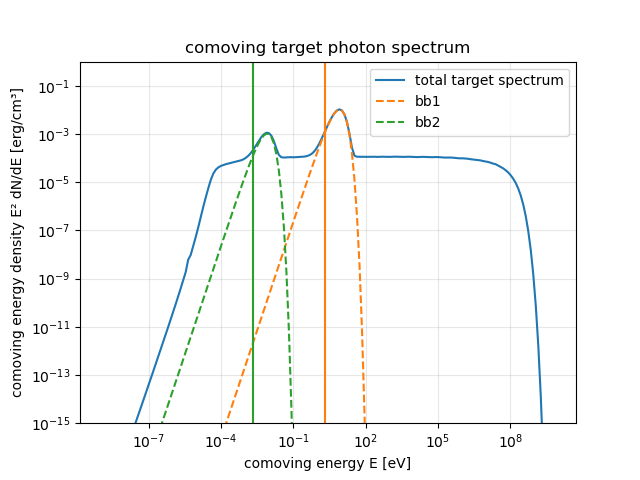

In [6]:
fig, axpt = plt.subplots()

energy = rad.get_photon_target_energy_grid()
axpt.loglog(energy*erg2eV, rad.get_photon_target_energy_density(), label="total target spectrum")
axpt.loglog(energy*erg2eV, rad.get_photon_target_energy_density_black_body("bb1"), ls="--", label="bb1")
axpt.loglog(energy*erg2eV, rad.get_photon_target_energy_density_black_body("bb2"), ls="--", label="bb2")
axpt.axvline(rad.get_target_black_body_temperature("bb1")*1e3 * rad.doppler_factor_bulk, color="tab:orange")
axpt.axvline(rad.get_target_black_body_temperature("bb2")*1e3 * rad.doppler_factor_bulk, color="tab:green")
axpt.legend()
axpt.set_xlabel("comoving energy E [eV]")
axpt.set_ylabel("comoving energy density E² dN/dE [erg/cm³]")
axpt.grid(alpha=0.3)
axpt.set_aspect("equal")
axpt.set_title("comoving target photon spectrum")
axpt.set_ylim(1e-15, 1e0)

It is also possible to read out the cooling timescales.
The Compton cooling timescales use the targets from above, and the code only uses the Thomson approximation, such that the dashed Compton line is more of a validation that Klein-Nishina effects can be ignored indeed.
From this the characteristic energies can be read out, corresponding to features in the particle spectra.

(1e-05, 3000000000.0)

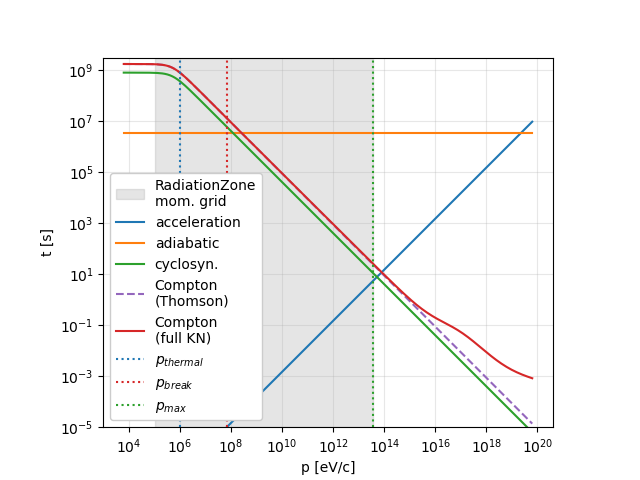

In [7]:
fig, axt = plt.subplots()
mom = rad.get_electron_momentum_grid()
axt.axvspan(mom[0]*erg2eV*c, mom[-1]*erg2eV*c, color="grey", alpha=0.2, label="RadiationZone\nmom. grid")
mom = np.logspace(-8, 8, 160) /c
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_acceleration(mom), c="tab:blue", label="acceleration")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_adiabatic(mom), c="tab:orange", label="adiabatic")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_cyclosyn(mom), c="tab:green", label="cyclosyn.")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton_thomson(mom), c="tab:purple", label="Compton\n(Thomson)", ls="--")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton(mom), c="tab:red", label="Compton\n(full KN)")
axt.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
axt.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
axt.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
axt.legend(framealpha=1)
axt.set_xlabel("p [eV/c]")
axt.set_ylabel("t [s]")
axt.grid(alpha=0.3)
axt.set_aspect("equal")
axt.set_ylim(1e-5, 3e9)


It is also possible to read out the particle densities, assuming the cooled/steady-state distributions

Text(0.5, 1.0, 'comoving electron spectrum')

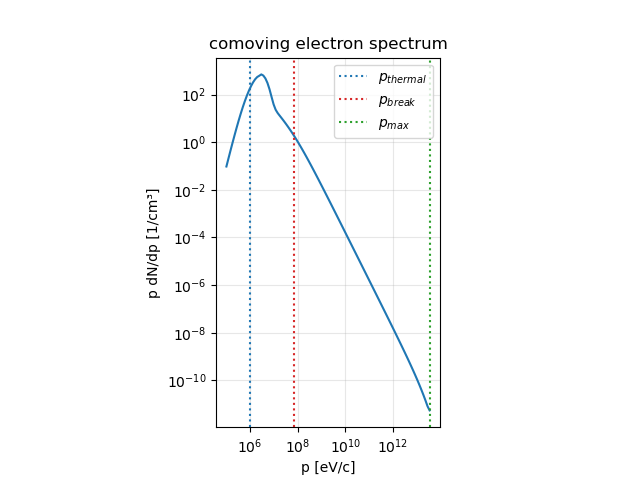

In [8]:
fig, ax = plt.subplots()

mom = rad.get_electron_momentum_grid()
ax.loglog(mom*erg2eV*c, rad.get_electron_momentum_number_density())
ax.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
ax.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
ax.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
ax.legend()
ax.set_xlabel("p [eV/c]")
ax.set_ylabel("p dN/dp [1/cm³]")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
ax.set_title("comoving electron spectrum")


The final photon emission can be read out as number flux, ie. EdN/dEdtdA, for the total emission and split up into components.

(1e-20, 1.0)

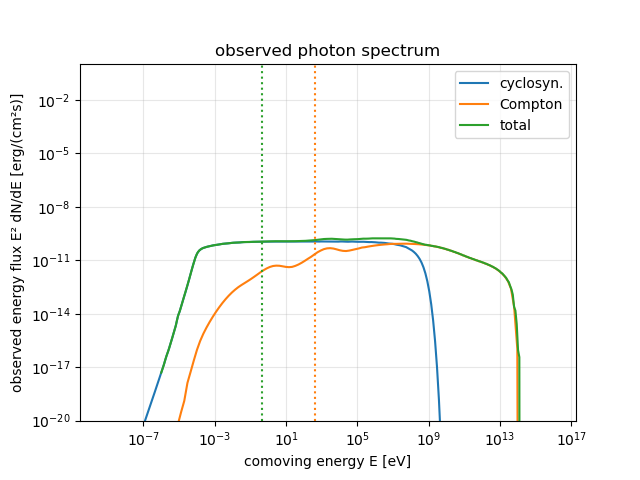

In [9]:
fig, axp = plt.subplots()

energy_syn = rad.get_observed_photon_energy_grid_electron_cyclosyn()
axp.loglog(energy_syn*erg2eV,energy_syn * rad.get_observed_photon_flux_electron_cyclosyn(), label="cyclosyn.")
energy_com = rad.get_observed_photon_energy_grid_electron_compton()
axp.loglog(energy_com*erg2eV,energy_com * rad.get_observed_photon_flux_electron_compton(), label="Compton")
energy_tot = rad.get_observed_photon_energy_grid_total()
axp.loglog(energy_tot*erg2eV,energy_tot * rad.get_observed_photon_flux_total(), label="total")

mainLF = rad.get_electron_gamma_grid()[np.argmax(rad.get_electron_momentum_grid()*rad.get_electron_momentum_number_density())]
# black bodies get scattered to energies avLF^2 * E_target
# E_target ~ 4 * kT * doppler, with the 4 accounting for the difference between max and average
axp.axvline(mainLF**2 * 4 * rad.get_target_black_body_temperature("bb1")*1e3 * rad.doppler_factor_bulk, color="tab:orange", ls=":")
axp.axvline(mainLF**2 * 4 * rad.get_target_black_body_temperature("bb2")*1e3 * rad.doppler_factor_bulk, color="tab:green", ls=":")
axp.legend()
axp.set_xlabel("comoving energy E [eV]")
axp.set_ylabel("observed energy flux E² dN/dE [erg/(cm²s)]")
axp.grid(alpha=0.3)
axp.set_aspect("equal")
axp.set_title("observed photon spectrum")
axp.set_ylim(1e-20, 1e0)

In [10]:
times = rad.get_computation_times()
print(f"Particle computation took {times[0]*1e-6:.1e} ms")
print(f"Cyclosyn. computation took {times[1]*1e-6:.1e} ms")
print(f"Compton computation took {times[2]*1e-6:.1e} ms")

Particle computation took 2.2e-01 ms
Cyclosyn. computation took 1.6e+00 ms
Compton computation took 5.3e+01 ms
